In [26]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve().parent))
from config import project_config
from evaluate import *

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [27]:
# Plot configs
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'

print(f"Plot config defined.")

Plot config defined.


In [28]:
"""
Load data from generated and real returns.
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}
CONDITION_FILES = [
    ('bear', 't-10r50i5v20.json'),
    ('bull', 't10r50i5v20.json'),
    ('vol', 't0r80i5v20.json'),
]

# Generated data
gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for cond_key, filename in CONDITION_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        gen_data[model][cond_key] = {
            'samples': np.array(payload['samples'], dtype=np.float64),
            'conditions': payload['conditions'],
        }

# Keys
gen_keys = [(model, cond_key) for model in MODEL_DIRS for cond_key, _ in CONDITION_FILES]
cond_keys = [cond_key for cond_key, _ in CONDITION_FILES]

# Real returns
PREP_DIR = Path('../../data/preprocessed')
real_windows = []
for fpath in sorted(PREP_DIR.glob('prep_data_*.json')):
    with open(fpath) as f:
        records = json.load(f)
        for rec in records:
            real_windows.append(rec['returns'])
real_np = np.array(real_windows, dtype=np.float64)   # (N_real, 64)

condition_titles = {
    'bear': 'Bear',
    'bull': 'Bull',
    'vol': 'Volatility',
}

# Print data info
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    print(f"Generated [{model} | {cond_key}]: {arr.shape[0]} sequences x {arr.shape[1]} steps")
print(f"Real: {real_np.shape[0]} sequences x {real_np.shape[1]} steps")


Generated [ca | bear]: 5000 sequences x 64 steps
Generated [ca | bull]: 5000 sequences x 64 steps
Generated [ca | vol]: 5000 sequences x 64 steps
Generated [ca-film | bear]: 5000 sequences x 64 steps
Generated [ca-film | bull]: 5000 sequences x 64 steps
Generated [ca-film | vol]: 5000 sequences x 64 steps
Real: 7079 sequences x 64 steps


In [56]:
"""
2.1 - Euclidean diversity.
"""

# Random sampling with limit
SEED = project_config.SEED
MAX_PAIRS = 100000
rng = np.random.default_rng(SEED)

# Generated returns
euc_gen = {}
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    idx_i, idx_j = sample_pair_indices(arr.shape[0], MAX_PAIRS, rng)
    d = euclidean_on_pairs(arr, idx_i, idx_j)
    euc_gen[(model, cond_key)] = d

# Real returns
idx_i_real, idx_j_real = sample_pair_indices(real_np.shape[0], MAX_PAIRS, rng)
euc_real = euclidean_on_pairs(real_np, idx_i_real, idx_j_real)

# Summary table 
print(f"{'Model':<10} {'Condition':>10} {'min':>10} {'q1':>10} {'median':>10} {'q3':>10} {'max':>10}")
print('-' * 80)
for model, cond_key in gen_keys:
    vals = euc_gen[(model, cond_key)]
    print(
        f"{model:<10} "
        f"{cond_key:>10} "
        f"{np.min(vals):>10.2f} {np.percentile(vals, 25):>10.2f} "
        f"{np.median(vals):>10.2f} {np.percentile(vals, 75):>10.2f} {np.max(vals):>10.2f}"
    )
print(
    f"{'real':<21} "
    f"{np.min(euc_real):>10.2f} {np.percentile(euc_real, 25):>10.2f} "
    f"{np.median(euc_real):>10.2f} {np.percentile(euc_real, 75):>10.2f} {np.max(euc_real):>10.2f}"
)

Model       Condition        min         q1     median         q3        max
--------------------------------------------------------------------------------
ca               bear       5.34      10.80      11.36      11.93     128.28
ca               bull       5.55      10.81      11.38      11.95     102.86
ca                vol       5.04      10.81      11.37      11.93     127.73
ca-film          bear       5.53      10.09      10.70      11.28      86.49
ca-film          bull       5.76      10.11      10.71      11.29      99.81
ca-film           vol       5.90      10.10      10.69      11.27     110.87
real                        3.84      10.73      11.22      11.69      14.10


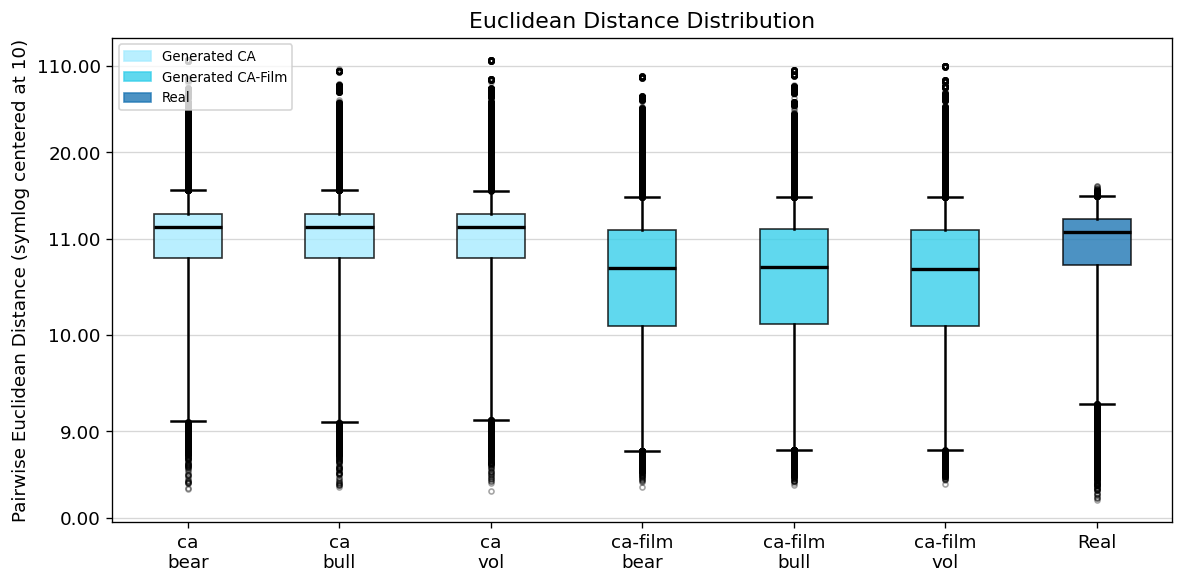

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Values
center_value = 10
euc_series = [euc_gen[(model, cond_key)] for model, cond_key in gen_keys] + [euc_real]
shifted_euc_series = [vals - center_value for vals in euc_series]

# Tick labels
tick_labels = [f'{model}\n{cond_key}' for model, cond_key in gen_keys] + ['Real']

# Boxplot
bp = ax.boxplot(
    shifted_euc_series,
    tick_labels=tick_labels,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)

# Set colors, transparency
for i, (model, _cond_key) in enumerate(gen_keys):
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.8)

bp['boxes'][-1].set_facecolor(C_REAL)
bp['boxes'][-1].set_alpha(0.8)

# Axis settings
ax.set_title('Euclidean Distance Distribution')
ax.set_ylabel('Pairwise Euclidean Distance (symlog centered at 10)')
ax.set_yscale('symlog', linthresh=1)

# Relabel shifted y ticks back to original scale
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f'{tick + center_value:.2f}' for tick in yticks])

# Legend
gen_ca_handle = mpatches.Patch(color=C_GEN_CA, alpha=0.8, label='Generated CA')
gen_cafilm_handle = mpatches.Patch(color=C_GEN_CAFILM, alpha=0.8, label='Generated CA-Film')
real_handle = mpatches.Patch(color=C_REAL, alpha=0.8, label='Real')
ax.legend(handles=[gen_ca_handle, gen_cafilm_handle, real_handle], loc='upper left', fontsize=8)

# Plot
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
"""
2.2 - DTW diversity metrics.
"""

DTW_MAX_PAIRS = 10000
print(f'Computing DTW distances with sampled pairs (max_pairs={DTW_MAX_PAIRS})...')

dtw_gen = {}
for model, cond_key in gen_keys:
    arr = gen_data[model][cond_key]['samples']
    idx_i, idx_j = sample_pair_indices(arr.shape[0], DTW_MAX_PAIRS, rng)
    d = dtw_on_pairs(arr, idx_i, idx_j)
    dtw_gen[(model, cond_key)] = d

    stats = summarize_distances(d)
    stats['dataset'] = f'generated_{model}'
    stats['condition'] = cond_key

idx_i_real_dtw, idx_j_real_dtw = sample_pair_indices(real_np.shape[0], DTW_MAX_PAIRS, rng)
dtw_real = dtw_on_pairs(real_np, idx_i_real_dtw, idx_j_real_dtw)
for cond_key in cond_keys:
    stats = summarize_distances(dtw_real)
    stats['dataset'] = 'real'
    stats['condition'] = cond_key

Computing DTW distances with sampled pairs (max_pairs=10000)...


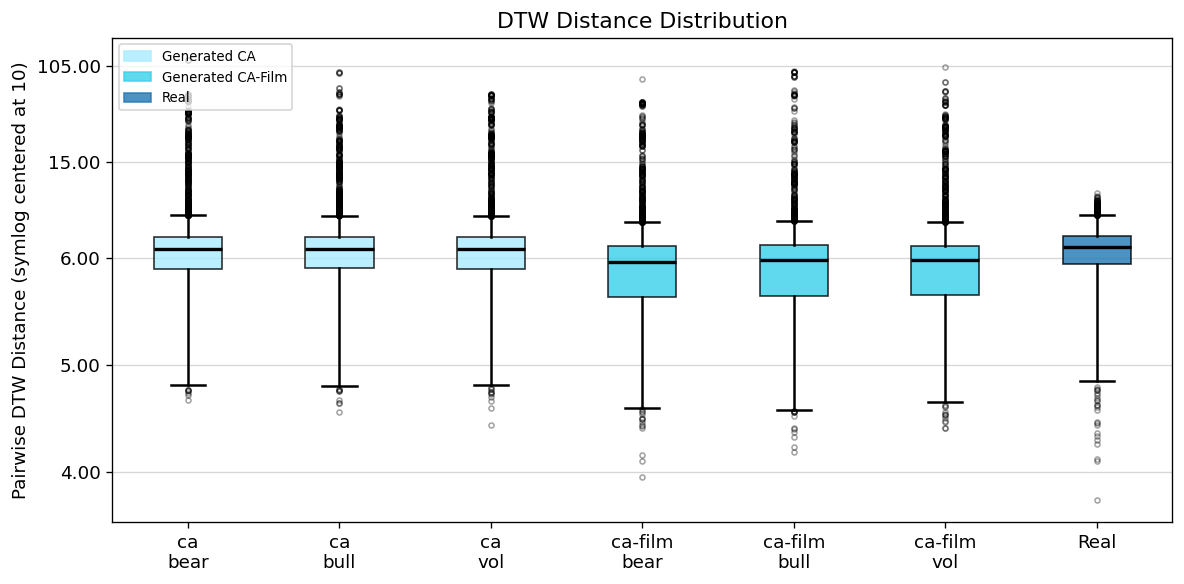

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))

# Values
center_value = 5
dtw_series = [dtw_gen[(model, cond_key)] for model, cond_key in gen_keys] + [dtw_real]
shifted_dtw_series = [vals - center_value for vals in dtw_series]

# Tick labels
tick_labels = [f'{model}\n{cond_key}' for model, cond_key in gen_keys] + ['Real']

# Boxplot
bp = ax.boxplot(
    shifted_dtw_series,
    tick_labels=tick_labels,
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.35, linestyle='none'),
)

# Set colors, transparency
for i, (model, _cond_key) in enumerate(gen_keys):
    color = C_GEN_CA if model == 'ca' else C_GEN_CAFILM
    bp['boxes'][i].set_facecolor(color)
    bp['boxes'][i].set_alpha(0.8)

bp['boxes'][-1].set_facecolor(C_REAL)
bp['boxes'][-1].set_alpha(0.8)

# Axis settings
ax.set_title('DTW Distance Distribution')
ax.set_ylabel('Pairwise DTW Distance (symlog centered at 10)')
ax.set_yscale('symlog', linthresh=1)

# Relabel shifted y ticks back to original scale
yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f'{tick + center_value:.2f}' for tick in yticks])

# Legend
gen_ca_handle = mpatches.Patch(color=C_GEN_CA, alpha=0.8, label='Generated CA')
gen_cafilm_handle = mpatches.Patch(color=C_GEN_CAFILM, alpha=0.8, label='Generated CA-Film')
real_handle = mpatches.Patch(color=C_REAL, alpha=0.8, label='Real')
ax.legend(handles=[gen_ca_handle, gen_cafilm_handle, real_handle], loc='upper left', fontsize=8)

# Plot
ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()